# 1. Regression with Concrete Compressive Strength

Universidad de Zaragoza

Names: Jorge Ruiz González & Hugo López Sola

NIAs: 826685, 875455

This is the notebook to train regression models and evaluate the performance of the models using the Concrete Compressive Strength Dataset
https://archive-beta.ics.uci.edu/dataset/165/concrete+compressive+strength

In [28]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/rmcantin/datasets/refs/heads/main/concrete.csv")
df

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [29]:
# Split the inputs X with respect to the target variable y
X = df.drop(columns=["strength"])
y = df["strength"]
print(X.shape, y.shape)

# Use StandardScaler to scale the input features and the output variable
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

(1030, 8) (1030,)


## 1.1 Split the data 
First of all, after you have your data, split it into the training, validation and test sets. Make 
sure you do not look at the test set until you report your final metrics

In [30]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (70%), validation (20%), and test (10%) sets

# For that purpose, we first split the dataset into training (70%) and temporary (30%) sets, and then we split the
# temporary set into validation (20%) and test (10%) sets.
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.33, random_state=42)

## 1.2 Explore the data 
Report first the size of the problem (how many samples are in the dataset? How many 
dimensions does your data have?). 
Plot and/or analyze in more depth the relation of each dimension with the output. For 
example, for each input variable and the output, 1) compute the correlation (you can use the 
numpy function corrcoef) and 2) plot the relation between the two variables in a 2-d graph 
(you can use the pyplot function scatter).

Training set: 721 samples, 8 dimensions
Validation set: 207 samples, 8 dimensions
Test set: 102 samples, 8 dimensions
Total: 1030 samples


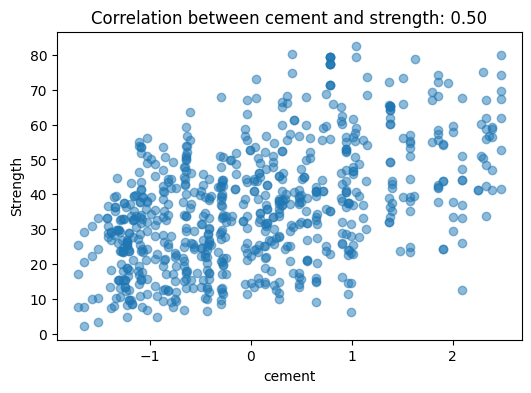

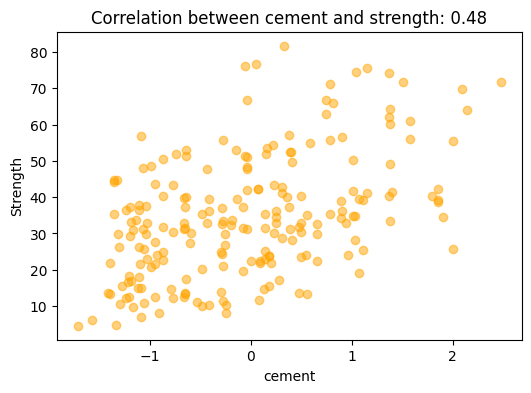

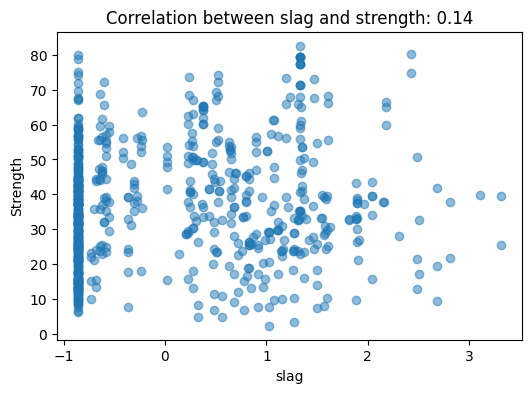

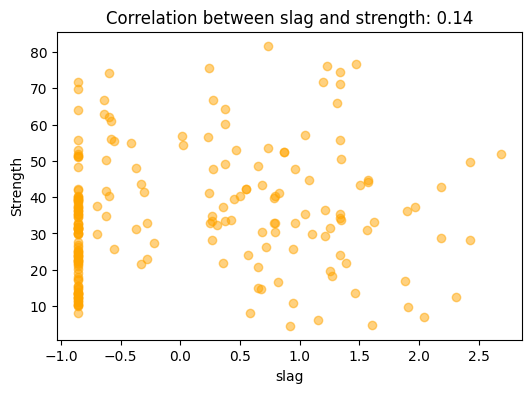

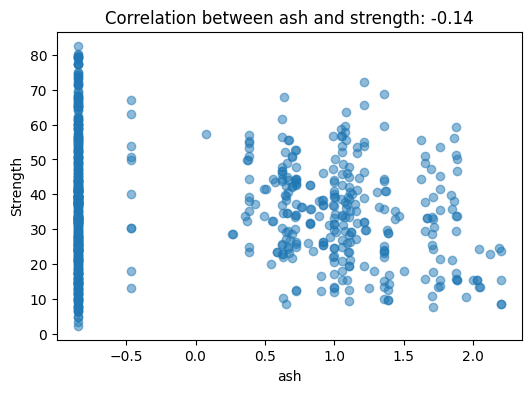

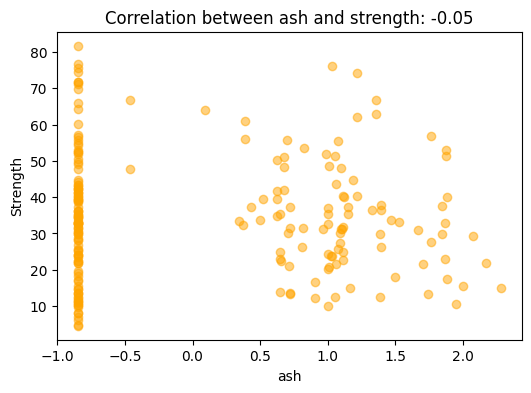

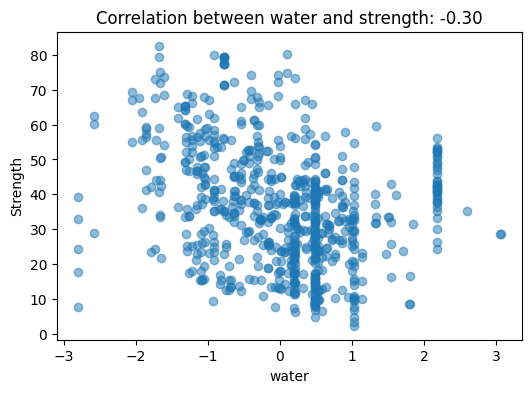

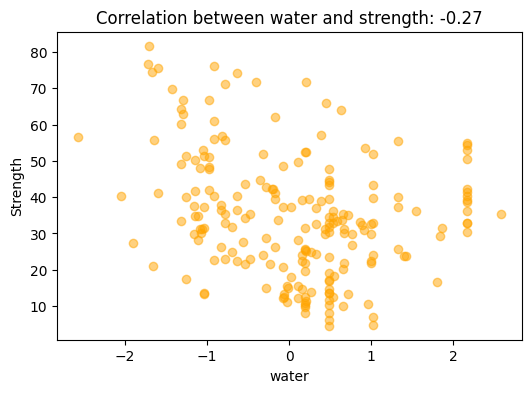

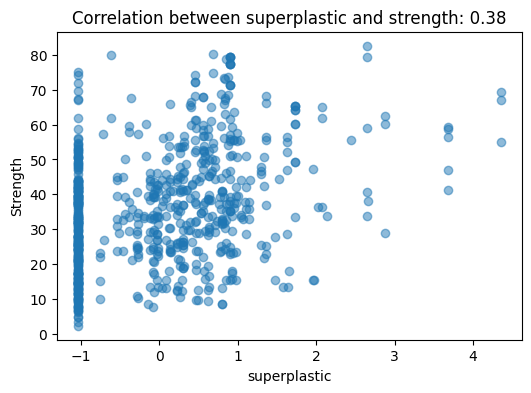

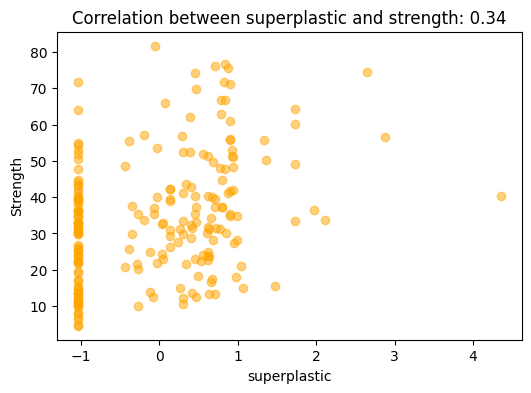

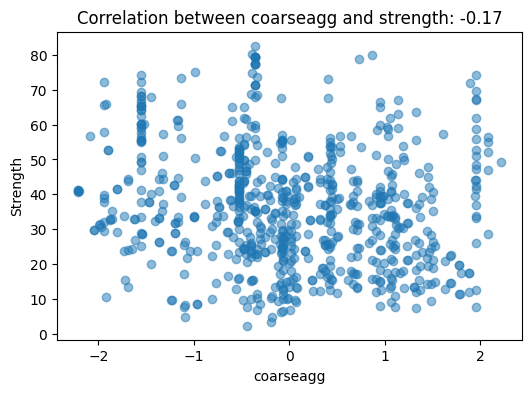

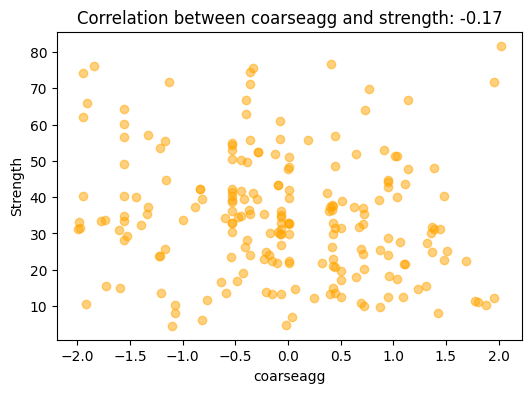

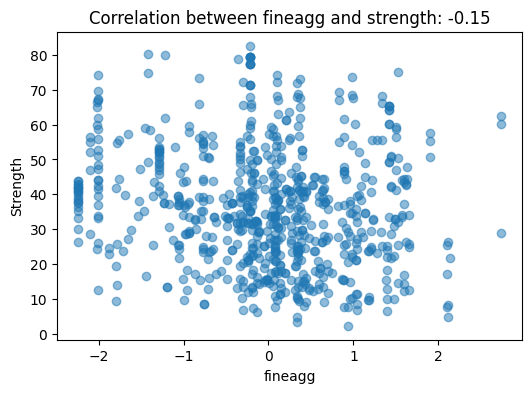

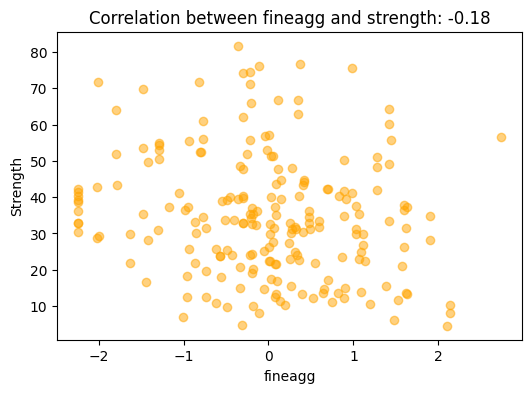

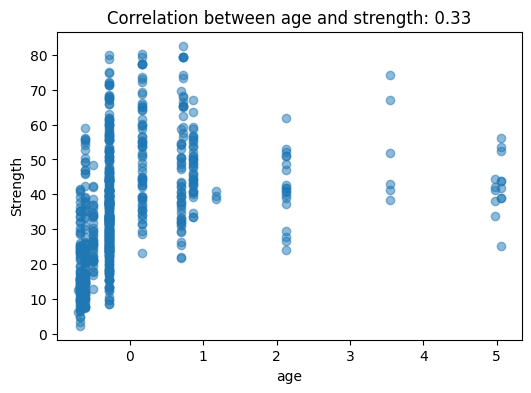

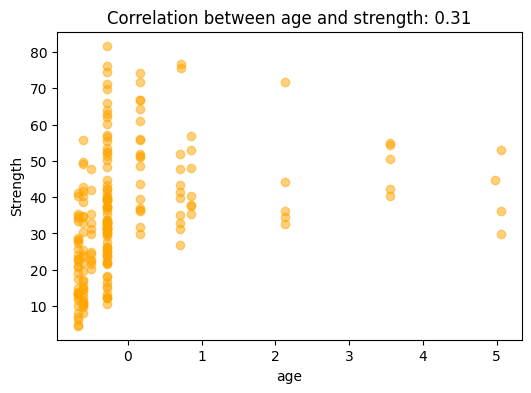

In [31]:
# Data Exploration

# For each train, validation, and test set, we print the number of samples and features.
n_samples_train, n_dim = X_train.shape
n_samples_val, _ = X_val.shape
n_samples_test, _ = X_test.shape
n_samples_total = n_samples_train + n_samples_val + n_samples_test

print(f"Training set: {n_samples_train} samples, {n_dim} dimensions")
print(f"Validation set: {n_samples_val} samples, {n_dim} dimensions")
print(f"Test set: {n_samples_test} samples, {n_dim} dimensions")
print(f"Total: {n_samples_total} samples", end="\n")

# Analysis of the relation of each dimension with the output. For each input variable, compute the correlation and plot
# the relation between the two variables in a 2D graph.
from numpy import corrcoef
from matplotlib import pyplot as plt

for i in range(n_dim):

    feature_name = X.columns[i]

    # Correlation between the input variable and the output variable for the training set (blue)
    correlation_matrix = corrcoef(X_train[:, i], y_train)
    correlation = correlation_matrix[0, 1]
    plt.figure(figsize=(6, 4))
    plt.scatter(X_train[:, i], y_train, alpha=0.5)
    plt.title(f"Correlation between {feature_name} and strength: {correlation:.2f}")
    plt.xlabel(feature_name)
    plt.ylabel("Strength")
    plt.show()

    # Correlation between the input variable and the output variable for the validation set (orange)
    correlation_matrix = corrcoef(X_val[:, i], y_val)
    correlation = correlation_matrix[0, 1]
    plt.figure(figsize=(6, 4))
    plt.scatter(X_val[:, i], y_val, c='orange', alpha=0.5)
    plt.title(f"Correlation between {feature_name} and strength: {correlation:.2f}")
    plt.xlabel(feature_name)
    plt.ylabel("Strength")
    plt.show()


---
# TODO: Analysis of the results obtained
# TODO: Manually exclude outliers (value 0) in variable "superplastic"
---

## 1.3 Train several promising models, decide on the best one and report 
expected performance 
Train the regression models we have seen in class (linear regression, polynomial models, 
ridge/Huber regression, RANSAC...) and others if you want to. If training is slow, consider 
doing quick explorations reducing the dataset size or the data dimensionality. Report several 
metrics and analyze their values. Extract conclusions and explain the results.

In [32]:
# Firstly we choose the metrics to evaluate the performance of each model.

# ----------------------------------------------------------------------------------------------------------------------
# MAE: Mean Absolute Error
# MedAE: Median Absolute Error
# MSE: Mean Squared Error
# RMSE: Root Mean Squared Error
# R2: R-squared
# ----------------------------------------------------------------------------------------------------------------------

# Function that given a model and the training and validation sets, fits the model to the training set and evaluates it
# on the validation set, returning the metrics.
# ----------------------------------------------------------------------------------------------------------------------
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)
    medae = median_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    return mae, medae, mse, rmse, r2

# Function that given a model and the metrics obtained, add the results to a pandas dataframe (2 decimals) and returns
# the updated dataframe.
# ----------------------------------------------------------------------------------------------------------------------
def add_results(dataframe, model_name, mae, medae, mse, rmse, r2):
    new_row = pd.DataFrame({
        "Model": [model_name],
        "MAE": [round(mae, 2)],
        "MedAE": [round(medae, 2)],
        "MSE": [round(mse, 2)],
        "RMSE": [round(rmse, 2)],
        "R2": [round(r2, 2)]
    })
    return pd.concat([dataframe, new_row], ignore_index=True)

# Dataframe to store the results of each model.
results = pd.DataFrame(columns=["Model", "MAE", "MedAE", "MSE", "RMSE", "R2"])

In [33]:
## Model 1: Linear Regression
# ----------------------------------------------------------------------------------------------------------------------
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
mae_model_1, medae_model_1, mse_model_1, rmse_model_1, r2_model_1 = evaluate(model_1, X_train, y_train, X_val, y_val)
results = add_results(results, "Linear Regression", mae_model_1, medae_model_1, mse_model_1, rmse_model_1, r2_model_1)

# Print the results of the models in a table.
print(results)

               Model   MAE  MedAE     MSE   RMSE   R2
0  Linear Regression  8.46   6.58  113.05  10.63  0.6


C:\Users\JORGE\AppData\Local\Temp\ipykernel_7376\1034716884.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([dataframe, new_row], ignore_index=True)


In [34]:
## Model 2: Polynomial Regression
# ----------------------------------------------------------------------------------------------------------------------

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# We are using Cross-Validation to find the best degree of the polynomial regression model.
degrees = [2, 3, 4, 5, 6, 7, 8, 12]
cv_scores = []

for degree in degrees:
    print(f"Testing degree: {degree}")
    
    poly_reg = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    scores = cross_val_score(poly_reg, X_train, y_train, cv=5, scoring='r2')
    print(f"Average CV score: {np.mean(scores)}")
    print()
    cv_scores.append(scores)

# Find the best degree based on the highest average CV score
best_degree = degrees[np.argmax([np.mean(s) for s in cv_scores])]
print(f"Best degree: {best_degree}")

Testing degree: 2
Average CV score: 0.7745175455170108

Testing degree: 3
Average CV score: 0.7384976735474755

Testing degree: 4
Average CV score: -1466965.903080218

Testing degree: 5
Average CV score: -376994901.81413

Testing degree: 6
Average CV score: -14067016855.609165

Testing degree: 7
Average CV score: -237125207.03398257

Testing degree: 8
Average CV score: -167378563.00948638

Testing degree: 12
Average CV score: -15148492633.408478

Best degree: 2


In [35]:
# Evaluate the best polynomial regression model on the validation set
poly_reg_best = make_pipeline(PolynomialFeatures(best_degree), LinearRegression())

mae_model_2, medae_model_2, mse_model_2, rmse_model_2, r2_model_2 = evaluate(poly_reg_best, X_train, y_train, X_val, y_val)
results = add_results(results, f"Polynomial Regression (deg={best_degree})", mae_model_2, medae_model_2, mse_model_2, rmse_model_2, r2_model_2)

print(results)

                           Model   MAE  MedAE     MSE   RMSE    R2
0              Linear Regression  8.46   6.58  113.05  10.63  0.60
1  Polynomial Regression (deg=2)  5.99   4.82   60.94   7.81  0.78


In [38]:
## Model 3: Polynomial Regression with L2 Regularization (Ridge Regression)
# ----------------------------------------------------------------------------------------------------------------------

# As in the previous model, we are using Cross-Validation to find the best degree of the polynomial regression model.
# This time we also need to use Cross-Validation to find the best regularization parameter alpha

degrees = [2, 3, 4, 5, 6, 7, 8, 12]
alphas = [0.001, 0.01, 0.1, 1, 1.5, 2.0, 5.0, 10.0]

results_ridge = pd.DataFrame(columns=["Degree", "Alpha", "Average CV Score"])

# We will use nested cross-validation to find the best combination of degree and alpha
from sklearn.linear_model import Ridge

for degree in degrees:
    for alpha in alphas:
        print(f"Testing degree: {degree}, alpha: {alpha}")
        
        poly_reg_ridge = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=alpha))
        scores = cross_val_score(poly_reg_ridge, X_train, y_train, cv=5, scoring='r2')

        results_ridge = pd.concat([results_ridge, pd.DataFrame({
            "Degree": [degree],
            "Alpha": [alpha],
            "Average CV Score": [round(np.mean(scores), 2)]
        })], ignore_index=True)

print(results_ridge)

# Find the best combination of degree and alpha based on the highest average CV score
best_row = results_ridge.loc[results_ridge["Average CV Score"].idxmax()]
best_degree_ridge = best_row["Degree"]
best_alpha_ridge = best_row["Alpha"]

print(f"Best degree: {best_degree_ridge}, Best alpha: {best_alpha_ridge}")

Testing degree: 2, alpha: 0.001
Testing degree: 2, alpha: 0.01
Testing degree: 2, alpha: 0.1
Testing degree: 2, alpha: 1
Testing degree: 2, alpha: 1.5
Testing degree: 2, alpha: 2.0
Testing degree: 2, alpha: 5.0
Testing degree: 2, alpha: 10.0
Testing degree: 3, alpha: 0.001
Testing degree: 3, alpha: 0.01
Testing degree: 3, alpha: 0.1


C:\Users\JORGE\AppData\Local\Temp\ipykernel_7376\3119062735.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_ridge = pd.concat([results_ridge, pd.DataFrame({


Testing degree: 3, alpha: 1
Testing degree: 3, alpha: 1.5
Testing degree: 3, alpha: 2.0
Testing degree: 3, alpha: 5.0
Testing degree: 3, alpha: 10.0
Testing degree: 4, alpha: 0.001
Testing degree: 4, alpha: 0.01
Testing degree: 4, alpha: 0.1
Testing degree: 4, alpha: 1
Testing degree: 4, alpha: 1.5
Testing degree: 4, alpha: 2.0
Testing degree: 4, alpha: 5.0
Testing degree: 4, alpha: 10.0
Testing degree: 5, alpha: 0.001
Testing degree: 5, alpha: 0.01
Testing degree: 5, alpha: 0.1
Testing degree: 5, alpha: 1
Testing degree: 5, alpha: 1.5
Testing degree: 5, alpha: 2.0
Testing degree: 5, alpha: 5.0
Testing degree: 5, alpha: 10.0
Testing degree: 6, alpha: 0.001
Testing degree: 6, alpha: 0.01
Testing degree: 6, alpha: 0.1
Testing degree: 6, alpha: 1
Testing degree: 6, alpha: 1.5
Testing degree: 6, alpha: 2.0
Testing degree: 6, alpha: 5.0
Testing degree: 6, alpha: 10.0
Testing degree: 7, alpha: 0.001
Testing degree: 7, alpha: 0.01
Testing degree: 7, alpha: 0.1
Testing degree: 7, alpha: 1
Test

c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:252: LinAlgWarning: Ill-conditioned matrix (rcond=6.68712e-17): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:252: LinAlgWarning: Ill-conditioned matrix (rcond=7.53126e-17): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:252: LinAlgWarning: Ill-conditioned matrix (rcond=5.97513e-17): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:252: LinAlgWarning: Ill-conditioned matrix (rcond=8.05885e-17): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)


Testing degree: 8, alpha: 0.01
Testing degree: 8, alpha: 0.1
Testing degree: 8, alpha: 1
Testing degree: 8, alpha: 1.5
Testing degree: 8, alpha: 2.0
Testing degree: 8, alpha: 5.0
Testing degree: 8, alpha: 10.0
Testing degree: 12, alpha: 0.001


...

c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Testing degree: 12, alpha: 10.0


c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


   Degree   Alpha  Average CV Score
0       2   0.001              0.77
1       2   0.010              0.77
2       2   0.100              0.77
3       2   1.000              0.78
4       2   1.500              0.78
..    ...     ...               ...
59     12   1.000       -1928518.87
60     12   1.500       -1352837.30
61     12   2.000       -2768909.55
62     12   5.000       -1034580.14
63     12  10.000       -1547602.26

[64 rows x 3 columns]
Best degree: 3, Best alpha: 5.0


c:\Users\JORGE\miniconda3\envs\ai\lib\site-packages\sklearn\linear_model\_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
